# Feature Engineering and Ensemble Learning

## House Price Prediction using the Ames Housing Dataset

### Objective
Improve house price prediction through feature engineering,
feature selection, preprocessing pipelines, and ensemble learning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'ML_Projects']

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_Projects/Ensemble_House_Price/data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.shape

(1460, 81)

In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [ ]:
df["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1168, 80), (292, 80), (1168,), (292,))

In [ ]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

In [ ]:
X_train_fe["TotalSF"] = (
    X_train_fe["TotalBsmtSF"]
    + X_train_fe["1stFlrSF"]
    + X_train_fe["2ndFlrSF"]
)

X_test_fe["TotalSF"] = (
    X_test_fe["TotalBsmtSF"]
    + X_test_fe["1stFlrSF"]
    + X_test_fe["2ndFlrSF"]
)

In [ ]:
X_train_fe["TotalSF"].head()

,TotalSF
254,2628
1066,2370
638,1592
799,2499
380,2717


In [ ]:
X_train_fe["TotalBathrooms"] = (
    X_train_fe["FullBath"]
    + 0.5 * X_train_fe["HalfBath"]
    + X_train_fe["BsmtFullBath"]
    + 0.5 * X_train_fe["BsmtHalfBath"]
)

X_test_fe["TotalBathrooms"] = (
    X_test_fe["FullBath"]
    + 0.5 * X_test_fe["HalfBath"]
    + X_test_fe["BsmtFullBath"]
    + 0.5 * X_test_fe["BsmtHalfBath"]
)

In [ ]:
X_train_fe["TotalBathrooms"].head()

,TotalBathrooms
254,2.0
1066,2.5
638,1.0
799,2.5
380,2.0


In [ ]:
X_train_fe["TotalPorchSF"] = (
    X_train_fe["OpenPorchSF"]
    + X_train_fe["EnclosedPorch"]
    + X_train_fe["3SsnPorch"]
    + X_train_fe["ScreenPorch"]
    + X_train_fe["WoodDeckSF"]
)

X_test_fe["TotalPorchSF"] = (
    X_test_fe["OpenPorchSF"]
    + X_test_fe["EnclosedPorch"]
    + X_test_fe["3SsnPorch"]
    + X_test_fe["ScreenPorch"]
    + X_test_fe["WoodDeckSF"]
)

In [ ]:
X_train_fe["TotalPorchSF"].head()

,TotalPorchSF
254,250
1066,40
638,492
799,264
380,242


In [ ]:
X_train_fe["HouseAge"] = (
    X_train_fe["YrSold"] - X_train_fe["YearBuilt"]
)

X_test_fe["HouseAge"] = (
    X_test_fe["YrSold"] - X_test_fe["YearBuilt"]
)

In [ ]:
X_train_fe["HouseAge"].head()

,HouseAge
254,53
1066,16
638,98
799,70
380,86


In [ ]:
X_train_fe[
    ["TotalSF", "TotalBathrooms", "TotalPorchSF", "HouseAge"]
].head()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge
254,2628,2.0,250,53
1066,2370,2.5,40,16
638,1592,1.0,492,98
799,2499,2.5,264,70
380,2717,2.0,242,86


In [ ]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

corr.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [ ]:
engineered_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HouseAge"
]

df_engineered_check = X_train_fe[engineered_features].copy()
df_engineered_check["SalePrice"] = y_train

df_engineered_check.corr()["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
TotalSF,0.765586
TotalBathrooms,0.621280
TotalPorchSF,0.388528
HouseAge,-0.516428


In [ ]:
#Data Preprocessing
numeric_features = X_train_fe.select_dtypes(
    include=["int64", "float64"]
).columns

len(numeric_features)

41

In [ ]:
categorical_features = X_train_fe.select_dtypes(
    include=["object"]
).columns

len(categorical_features)

43

In [ ]:
categorical_features

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
numeric_features

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBathrooms',
       'TotalPorchSF', 'HouseAge'],
      dtype='object')

In [ ]:
#Remove ID as it doesn't describe the characteristics of house
X_train_fe = X_train_fe.drop("Id", axis=1)
X_test_fe = X_test_fe.drop("Id", axis=1)

In [ ]:
#Recalculation
numeric_features = X_train_fe.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train_fe.select_dtypes(
    include=["object"]
).columns

len(numeric_features), len(categorical_features)

(40, 43)

In [ ]:
#Convert MSSubClass to categorical(as it looks numeric but
#are codes for diff building classes not measurements)
X_train_fe["MSSubClass"] = X_train_fe["MSSubClass"].astype(str)
X_test_fe["MSSubClass"] = X_test_fe["MSSubClass"].astype(str)
#.astype(str) converts 20 into "20"

In [ ]:
#Updated feature groups
numeric_features = X_train_fe.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train_fe.select_dtypes(
    include=["object"]
).columns

len(numeric_features), len(categorical_features)

(39, 44)

In [ ]:
from sklearn.impute import SimpleImputer
numeric_imputer = SimpleImputer(strategy = "median")

In [ ]:
categorical_imputer = SimpleImputer(strategy = "most_frequent")

In [ ]:
#Encoding categorical features
from sklearn.preprocessing import OneHotEncoder
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler
numeric_scaler = StandardScaler()

In [ ]:
#Build numerical pipeline
from sklearn.pipeline import Pipeline
numeric_pipeline = Pipeline(
    steps = [
        ("imputer", numeric_imputer),
        ("scaler", numeric_scaler)
    ]
)
#Pipeline(..)creates sequence of preprocessing steps

In [ ]:
#Build categorical pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", categorical_imputer),
        ("encoder", categorical_encoder)
    ]
)

In [ ]:
#ColumnTransformer combines pipelines
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [ ]:
#Fit preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train_fe)

In [ ]:
X_train_processed.shape

(1168, 303)

In [ ]:
#transform test data
X_test_processed = preprocessor.transform(X_test_fe)

In [ ]:
X_test_processed.shape

(292, 303)

In [ ]:
#both should've had 303 columns(test had 264)
set(X_train_fe.columns) - set(X_test_fe.columns), set(X_test_fe.columns) - set(X_train_fe.columns)

(set(), set())

In [ ]:
preprocessor.get_feature_names_out().shape

(303,)

In [ ]:
#refit preprocessor
X_train_processed = preprocessor.fit_transform(X_train_fe)

In [ ]:
X_train_processed.shape

(1168, 303)

In [ ]:
len(numeric_features), len(categorical_features)

(39, 44)

In [ ]:
preprocessor.named_transformers_["cat"].named_steps["encoder"].categories_

[array(['120', '160', '180', '190', '20', '30', '40', '45', '50', '60',
        '70', '75', '80', '85', '90'], dtype=object),
 array(['C (all)', 'FV', 'RH', 'RL', 'RM'], dtype=object),
 array(['Grvl', 'Pave'], dtype=object),
 array(['Grvl', 'Pave'], dtype=object),
 array(['IR1', 'IR2', 'IR3', 'Reg'], dtype=object),
 array(['Bnk', 'HLS', 'Low', 'Lvl'], dtype=object),
 array(['AllPub', 'NoSeWa'], dtype=object),
 array(['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside'], dtype=object),
 array(['Gtl', 'Mod', 'Sev'], dtype=object),
 array(['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr',
        'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel',
        'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown',
        'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber',
        'Veenker'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNe',
        'RRNn'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', '

In [ ]:
X_train_processed.shape

(1168, 303)

In [ ]:
preprocessor.transform(X_train_fe).shape

(1168, 303)

In [ ]:
#Check 2 preprocessing branches separately
num_output = preprocessor.named_transformers_["num"].transform(
    X_train_fe[numeric_features]
)

cat_output = preprocessor.named_transformers_["cat"].transform(
    X_train_fe[categorical_features]
)

num_output.shape, cat_output.shape

((1168, 39), (1168, 264))

In [ ]:
#Retransform test set
X_test_processed = preprocessor.transform(X_test_fe)

In [ ]:
X_test_processed.shape #292 test houses x 303 processed features

(292, 303)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
#Build RF ML pipeline(connect preprocessor & rf)
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [ ]:
#Train rf pipeline(1st ensemble model)
rf_pipeline.fit(X_train_fe, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',...
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [ ]:
#Make predictions on test set(find how well it performs on untrained houses)
y_pred_rf = rf_pipeline.predict(X_test_fe)

In [ ]:
#Calculate R^2(measure how much variation in house prices model explains)
from sklearn.metrics import r2_score
rf_r2 = r2_score(y_test, y_pred_rf)
rf_r2

0.8846022306526603

### Random Forest Baseline Results

First Week 3 ensemble model, **Random Forest**, achieved an **R² score of 0.8846** on the held-out test set.

This means that the model explains approximately **88.46% of the variation in house prices**.

Importantly, this result was obtained **before hyperparameter tuning**, so there is still potential for improvement.

#### Week 2 vs Week 3

| Model | R² Score |
|---|---:|
| Week 2 — Decision Tree | 0.7955 |
| Week 3 — Random Forest | **0.8846** |

The Random Forest significantly outperformed the Decision Tree from Week 2.

This demonstrates the advantage of **ensemble learning**: instead of relying on a single decision tree, Random Forest combines predictions from multiple trees to produce a more robust and accurate model.

> **Key takeaway:** Random Forest has already provided a substantial improvement over our Week 2 Decision Tree, even without hyperparameter tuning.

In [ ]:
#Calc MAE(how many $ r predictions away from actual house price)
from sklearn.metrics import mean_absolute_error
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mae

17586.048886986304

### Random Forest — Mean Absolute Error (MAE)

The Random Forest achieved a **Mean Absolute Error (MAE) of approximately $17,586**.

This means that, on average, the model's predicted house prices differ from the actual prices by about **$17,586** in absolute terms.

A lower MAE indicates better predictive performance.

In [ ]:
#Calc RMSE(it penalizes large errors heavily)
from sklearn.metrics import mean_squared_error
import numpy as np
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_rmse

np.float64(29751.277862905896)

### Random Forest — Root Mean Squared Error (RMSE)

The Random Forest achieved an **RMSE of approximately $29,751**.

RMSE measures the typical magnitude of prediction errors while giving **greater weight to larger errors** than MAE.

Since RMSE is higher than MAE, this indicates that some predictions have relatively large errors.

A lower RMSE indicates better predictive performance.

In [ ]:
#Record Baseline Results
import pandas as pd
results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R²": rf_r2
    }
])
results

,Model,MAE,RMSE,R²
0,Random Forest,17586.048887,29751.277863,0.884602


In [ ]:
#Gradient Boosting(GB)it builds trees one after another(each tree corrects errors of previous trees)
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
#Create GB moodel
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [ ]:
#Build GB pipeline
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gb_model)
    ]
)

In [ ]:
#Train GB
gb_pipeline.fit(X_train_fe, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',...
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [ ]:
y_pred_gb = gb_pipeline.predict(X_test_fe)

In [ ]:
#Calc GB metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)
gb_mae, gb_rmse, gb_r2

(15754.799686101756, np.float64(26138.29610069761), 0.9109281007621849)

In [ ]:
results.loc[len(results)] = {
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R²": gb_r2
}
results

,Model,MAE,RMSE,R²
0,Random Forest,17586.048887,29751.277863,0.884602
1,Gradient Boosting,15754.799686,26138.296101,0.910928


Compared with our Random Forest baseline, Gradient Boosting achieved:
- Lower MAE: **$15,755 vs. $17,586**
- Lower RMSE: **$26,138 vs. $29,751**
- Higher R²: **0.9109 vs. 0.8846**

Therefore, GB currently performs better than RF on test set.

In [ ]:
#XGBoost(Extreme GB)
import xgboost as xgb
xgb.__version__

'3.3.0'

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)


### XGBoost Parameters
- **n_estimators = 200:** Number of boosting trees.
- **learning_rate = 0.05:** Controls each tree's contribution.
- **max_depth = 3:** Limits tree depth to reduce overfitting.
- **random_state = 42:** Ensures reproducible results.
- **n_jobs = -1:** Uses all available CPU cores.

In [ ]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

In [ ]:
xgb_pipeline.fit(X_train_fe, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred_xgb = xgb_pipeline.predict(X_test_fe)

In [ ]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae, xgb_rmse, xgb_r2

(15773.2255859375, np.float64(25528.0476339261), 0.9150386452674866)

In [ ]:
results.loc[len(results)] = {
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R²": xgb_r2
}
results

,Model,MAE,RMSE,R²
0,Random Forest,17586.048887,29751.277863,0.884602
1,Gradient Boosting,15754.799686,26138.296101,0.910928
2,XGBoost,15773.225586,25528.047634,0.915039


In [ ]:
#LightGBM(advanced GB algo)
import lightgbm as lgb
lgb.__version__

'4.6.0'

In [ ]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

In [ ]:
lgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", lgb_model)
    ]
)

In [ ]:
lgb_pipeline.fit(X_train_fe, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3829
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 191
[LightGBM] [Info] Start training from score 181441.541952
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',...
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 LGBMRegressor(learning_rate=0.05, max_depth=3,
                               n_estimators=200, n_jobs=-1, random_state=42))])

In [ ]:
y_pred_lgb = lgb_pipeline.predict(X_test_fe)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_lgb.shape

(292,)

In [ ]:
lgb_mae = mean_absolute_error(y_test, y_pred_lgb)
lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
lgb_r2 = r2_score(y_test, y_pred_lgb)
lgb_mae, lgb_rmse, lgb_r2

(17148.418015212115, np.float64(29884.813348141393), 0.8835640043553284)

In [ ]:
results.loc[len(results)] = {
    "Model": "LightGBM",
    "MAE": lgb_mae,
    "RMSE": lgb_rmse,
    "R²": lgb_r2
}
results

,Model,MAE,RMSE,R²
0,Random Forest,17586.048887,29751.277863,0.884602
1,Gradient Boosting,15754.799686,26138.296101,0.910928
2,XGBoost,15773.225586,25528.047634,0.915039
3,LightGBM,17148.418015,29884.813348,0.883564


### Baseline Ensemble Comparison

Four ensemble models were evaluated using MAE, RMSE, and R². XGBoost currently achieves the best **R² (0.9150)** and **RMSE ($25,528.05)**, while Gradient Boosting achieves the best **MAE ($15,754.80)**.

In [ ]:
#CV(5 fold) for XGB(started with XGB as it has best R^2)
from sklearn.model_selection import cross_val_score
xgb_cv_scores = cross_val_score(
    xgb_pipeline,
    X_train_fe,
    y_train,
    cv=5,
    scoring="r2"
)
xgb_cv_scores

array([0.87447244, 0.77257824, 0.86838156, 0.89184189, 0.88349402])

In [ ]:
#Avg cv score
xgb_cv_mean = xgb_cv_scores.mean()
xgb_cv_mean

np.float64(0.8581536293029786)

### XGBoost Cross-Validation

XGBoost achieved a mean **5-fold cross-validation R² of 0.8582**.

The score is lower than the single test-set R² of 0.9150, showing why cross-validation provides a more robust estimate of model performance.

In [ ]:
#RF CV
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train_fe,
    y_train,
    cv=5,
    scoring="r2"
)
rf_cv_scores

array([0.88247285, 0.77246201, 0.82892679, 0.88635101, 0.86809101])

In [ ]:
rf_cv_mean = rf_cv_scores.mean()
rf_cv_mean

np.float64(0.8476607354031127)

### Random Forest Cross-Validation

Random Forest achieved a mean **5-fold cross-validation R² of 0.8477**, slightly below XGBoost's 0.8582.

In [ ]:
#GB cv
gb_cv_scores = cross_val_score(
    gb_pipeline,
    X_train_fe,
    y_train,
    cv=5,
    scoring="r2"
)
gb_cv_scores

array([0.88660527, 0.79332041, 0.86840149, 0.88069284, 0.89283928])

In [ ]:
gb_cv_mean = gb_cv_scores.mean()
gb_cv_mean

np.float64(0.8643718596337472)

### Gradient Boosting Cross-Validation

Gradient Boosting achieved a mean **5-fold cross-validation R² of 0.8644**, currently the highest among the evaluated models.

In [ ]:
#LGB CV
lgb_cv_scores = cross_val_score(
    lgb_pipeline,
    X_train_fe,
    y_train,
    cv=5,
    scoring="r2"
)
lgb_cv_scores

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3612
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 182
[LightGBM] [Info] Start training from score 181121.274090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3598
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 182
[LightGBM] [Info] Start training from score 179912.635974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3605
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 177
[LightGBM] [Info] Start training from score 182516.069593
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3604
[LightGBM] [Info] Number of data points in the train set: 935, number of used features: 180
[LightGBM] [Info] Start training from score 182235.731551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([0.88016342, 0.83236944, 0.83994047, 0.89367776, 0.91056662])

In [ ]:
lgb_cv_mean = lgb_cv_scores.mean()
lgb_cv_mean

np.float64(0.8713435420146247)

### LightGBM Results

- **R² Score:** 0.8713

The LightGBM model achieved an **R² score of 0.8713**, meaning it explains approximately **87.13% of the variation in house prices**.

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"],
    "R2 Score": [
        rf_r2,
        gb_r2,
        xgb_r2,
        lgb_r2
    ],
    "RMSE": [
        rf_rmse,
        gb_rmse,
        xgb_rmse,
        lgb_rmse
    ],
    "MAE": [
        rf_mae,
        gb_mae,
        xgb_mae,
        lgb_mae
    ]
})
results

,Model,R2 Score,RMSE,MAE
0,Random Forest,0.884602,29751.277863,17586.048887
1,Gradient Boosting,0.910928,26138.296101,15754.799686
2,XGBoost,0.915039,25528.047634,15773.225586
3,LightGBM,0.883564,29884.813348,17148.418015


### Baseline Model Comparison

Four ensemble models were evaluated using **R², RMSE, and MAE**. XGBoost achieved the highest R² and lowest RMSE, while Gradient Boosting achieved the lowest MAE.

In [ ]:
#Hyperparameter Tuning(GridSearchCV on XGBoost)
from sklearn.model_selection import GridSearchCV

In [ ]:
#Define XGB model
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    enable_categorical=True
)

In [ ]:
#Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

In [ ]:
#Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1               #shows progress while gridscv is running
)

In [ ]:
param_grid_tuned = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

grid_search_tuned = GridSearchCV(
    estimator=xgb_pipeline, # Use the pipeline here to include preprocessing
    param_grid=param_grid_tuned,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search_tuned.fit(X_train_fe, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF...
                                                     max_delta_step=None,
                                                     max_depth=3,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [ ]:
grid_search_tuned.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__n_estimators': 300,
 'model__subsample': 0.8}

In [ ]:
grid_search_tuned.best_score_

np.float64(0.8689304828643799)

In [ ]:
#Get tuned model
best_xgb = grid_search_tuned.best_estimator_

In [ ]:
y_pred_tuned = best_xgb.predict(X_test_fe)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print("Tuned XGBoost R²:", r2_tuned)
print("Tuned XGBoost RMSE:", rmse_tuned)
print("Tuned XGBoost MAE:", mae_tuned)

Tuned XGBoost R²: 0.9227585792541504
Tuned XGBoost RMSE: 24340.63861117863
Tuned XGBoost MAE: 15236.767578125


## Hyperparameter Tuning — Tuned XGBoost

GridSearchCV was used with 5-fold cross-validation to test 54 different hyperparameter combinations (270 total fits).

### Best Hyperparameters
- **Learning Rate:** 0.05
- **Maximum Depth:** 3
- **Number of Estimators:** 300
- **Subsample:** 0.8

**Best Cross-Validation R²:** 0.8689

### Tuned Model Test Performance
- **R² Score:** 0.9228 (92.28%)
- **RMSE:** 24,340.64
- **MAE:** 15,236.77

The tuned XGBoost model improved upon the original XGBoost model, achieving a higher R² score and lower RMSE and MAE.

In [ ]:
#Explainable AI[XAI](SHAP) shapely additive explanations
import shap

In [ ]:
#extracted preprocessed test data for shap
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test_fe)

In [ ]:
#Create SHAP explainer(extract actual xgb model)
explainer = shap.TreeExplainer(best_xgb.named_steps["model"])

In [ ]:
#calc shap values
shap_values = explainer.shap_values(X_test_transformed)

In [ ]:
#check shap values
shap_values.shape

(292, 303)

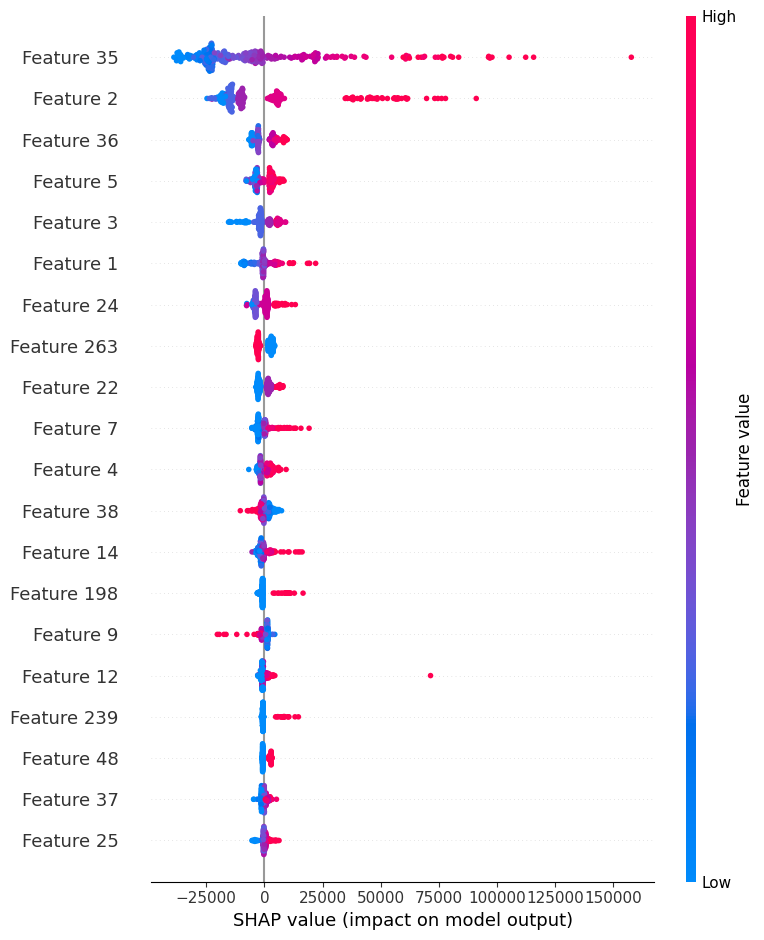

In [643]:
shap.summary_plot(shap_values, X_test_transformed, show=False)

plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import joblib
joblib.dump(grid_search_tuned.best_estimator_, "tuned_xgboost_model.pkl")

['tuned_xgboost_model.pkl']

In [ ]:
from google.colab import files
files.download("tuned_xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [644]:
import os

os.makedirs("../plots", exist_ok=True)

plt.savefig("../plots/xgboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.savefig(
    "/content/drive/MyDrive/ML_Projects/Ensemble_House_Price/plots/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [650]:
from google.colab import files
files.download("shap_summary_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.listdir("../plots")

['xgboost_feature_importance.png']

— Feature Engineering and Ensemble Learning: Final Summary

This project focused on improving machine learning performance through feature engineering, preprocessing pipelines, and ensemble learning algorithms.

Feature Engineering & Preprocessing

- Performed feature engineering and feature selection to prepare the dataset.
- Applied appropriate feature scaling.
- Encoded categorical variables using preprocessing techniques.
- Built a preprocessing and modeling pipeline to ensure consistent transformations.

Ensemble Model Comparison

Four ensemble learning algorithms were trained and evaluated:

Model| R² Score| RMSE| MAE
Random Forest| 0.8846| 29,751.28| 17,586.05
Gradient Boosting| 0.9109| 26,138.30| 15,754.80
XGBoost| 0.9150| 25,528.05| 15,773.23
LightGBM| 0.8836| 29,884.81| 17,148.42

XGBoost achieved the best performance among the initial ensemble models.

Hyperparameter Optimization

XGBoost was further optimized using GridSearchCV with 5-fold cross-validation.

Best Parameters:

- Learning Rate: "0.05"
- Maximum Depth: "3"
- Number of Estimators: "300"
- Subsample: "0.8"

Best Cross-Validation R²: "0.8689"

Final Optimized Model

The tuned XGBoost model achieved:

- R² Score: "0.9228" (92.28%)
- RMSE: "24,340.64"
- MAE: "15,236.77"

The tuned model improved over the original XGBoost model, demonstrating the benefit of hyperparameter optimization.

Feature Importance Analysis

SHAP (SHapley Additive exPlanations) was used to analyze feature importance and understand how different features contributed to the XGBoost model's predictions.

Conclusion

The project successfully demonstrated an end-to-end feature engineering and ensemble learning workflow. Among the evaluated models, the tuned XGBoost model provided the strongest predictive performance and was selected as the final optimized machine learning model.

In [646]:
readme = """
# Week 3: Feature Engineering and Ensemble Learning

## Project Objective

The objective of this project is to improve house price prediction performance using feature engineering, preprocessing pipelines, ensemble learning algorithms, and hyperparameter tuning.

## Dataset

The project uses the Kaggle House Prices dataset.

## Workflow

1. Data loading and exploration
2. Feature engineering
3. Handling numerical and categorical features
4. Feature scaling
5. One-hot encoding
6. Preprocessing pipeline
7. Ensemble model training
8. Model comparison
9. Cross-validation
10. Hyperparameter tuning using GridSearchCV
11. Feature importance analysis
12. SHAP-based model interpretation
13. Final model evaluation

## Ensemble Models

The following models were compared:

- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

## Model Comparison

| Model | R² Score | RMSE | MAE |
|---|---:|---:|---:|
| Random Forest | 0.8846 | 29751.28 | 17586.05 |
| Gradient Boosting | 0.9109 | 26138.30 | 15754.80 |
| XGBoost | 0.9150 | 25528.05 | 15773.23 |
| LightGBM | 0.8836 | 29884.81 | 17148.42 |

## Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation was used to optimize the XGBoost model.

Best parameters:

- Learning rate: 0.05
- Max depth: 3
- Number of estimators: 300
- Subsample: 0.8

## Final Tuned XGBoost Results

- R² Score: 0.9228
- RMSE: 24340.64
- MAE: 15236.77

The tuned XGBoost model achieved the best performance among the evaluated models.

## Explainability

Feature importance analysis and SHAP were used to understand which features contributed most to the model's predictions.
## SHAP Feature Importance

SHAP was used to explain the XGBoost model and identify how individual features contribute to the model's predictions.

![SHAP Summary Plot](plot/shap_summary_plot.png)
## Final Model

The final tuned XGBoost pipeline was saved as:

`tuned_xgboost_model.pkl`

## Conclusion

Feature engineering, preprocessing pipelines, ensemble learning, cross-validation, and hyperparameter tuning significantly improved the house price prediction model. The tuned XGBoost model achieved an R² score of approximately 0.923, making it the final selected model for this project.
"""

with open(
    "/content/drive/MyDrive/ML_Projects/Ensemble_House_Price/README.md",
    "w"
) as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
xgboost
lightgbm
shap
joblib
"""

path = "/content/drive/MyDrive/ML_Projects/Ensemble_House_Price/requirements.txt"

with open(path, "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!
